In [35]:
import numpy as np
import math, random

In [36]:
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data}, grad={self.grad})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        
        def _backward():
            self.grad += out.grad
            other.grad += out.grad
        out._backward = _backward
        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')
        
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out

    def __sub__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        return self + (other * -1)

    def sigmoid(self):
        # Sigmoid formula: 1 / (1 + e^-x)
        s = 1 / (1 + math.exp(-self.data))
        out = Value(s, (self,), 'sigmoid')
        
        def _backward():
            # Derivative of sigmoid: s * (1 - s)
            self.grad += s * (1.0 - s) * out.grad
        out._backward = _backward
        return out

    def backward(self):
        # Topological sort to compute gradients in correct reverse order
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

In [37]:
# Define the network architecture
n_inputs = 3 # Kept small here so your graph visual stays easy to read
n_hidden = 2

# Seed random numbers for reproducibility
random.seed(42)

In [38]:
# Initialize inputs as Value objects
inputs = [Value(1.0, label='x0'), Value(2.0, label='x1'), Value(3.0, label='x2')]
target = Value(0.7, label='target')

# Initialize weights randomly as Value objects
weights = [[Value(random.uniform(-1, 1), label=f'w_{i}_{j}') for j in range(n_hidden)] for i in range(n_inputs)]

In [39]:
# --- FORWARD PASS ---
# Compute the hidden layer neurons manually
hidden_layer = []
for j in range(n_hidden):
    # Weighted sum: x0*w0j + x1*w1j + x2*w2j
    weighted_sum = Value(0.0)
    for i in range(n_inputs):
        weighted_sum = weighted_sum + (inputs[i] * weights[i][j])
    
    # Apply activation function
    activated_neuron = weighted_sum.sigmoid()
    activated_neuron.label = f'h{j}'
    hidden_layer.append(activated_neuron)

# For this simple setup, let's say the final output is the mean of our hidden layer
output = (hidden_layer[0] + hidden_layer[1]) * 0.5
output.label = 'output'

# Loss function: Mean Squared Error (target - output)^2
error = target - output
loss = error * error
loss.label = 'Loss'

# --- BACKWARD PASS ---
loss.backward()

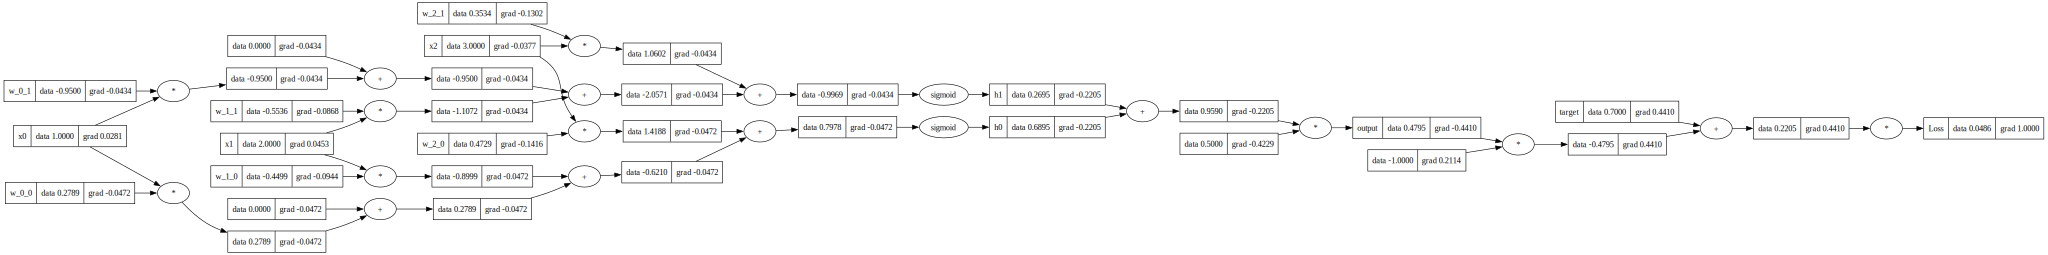

In [40]:
# --- GRAPHVIZ VISUALIZATION ---
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})
    nodes, edges = trace(root)
    
    for n in nodes:
        uid = str(id(n))
        # Create a rectangular record node showing data and gradient
        label_text = f"{{ {n.label} | data {n.data:.4f} | grad {n.grad:.4f} }}" if n.label else f"{{ data {n.data:.4f} | grad {n.grad:.4f} }}"
        dot.node(name=uid, label=label_text, shape='record')
        
        # If this node was created by an operation, link it to an operation node
        if n._op:
            dot.node(name=uid + n._op, label=n._op)
            dot.edge(uid + n._op, uid)
            
    for n1, n2 in edges:
        # Link children to parent operations
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
        
    return dot

# Generate the graph starting from the loss node (or the output node)
img = draw_dot(loss)
img # If running in a Jupyter Notebook, this will render the graph inline